# CIC-IDS2017 — Milestone 1 Data Analysis

This notebook discovers all CSV files under `dataset/raw`, cleans column names and labels, audits data quality, explores class balance and numeric features, and writes reproducible artifacts to `results/eda`. It does not download the dataset.

In [1]:
from __future__ import annotations

import json
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.column_utils import clean_column_names

RAW_DIR = PROJECT_ROOT / 'dataset' / 'raw'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Set EDA_SAMPLE_ROWS_PER_FILE (for example 100000) for a lower-memory exploratory run.
SAMPLE_ROWS_PER_FILE = int(os.getenv('EDA_SAMPLE_ROWS_PER_FILE', '0')) or None
print(f'Project: {PROJECT_ROOT.resolve()}')
print(f'Per-file row limit: {SAMPLE_ROWS_PER_FILE or "all rows"}')

Project: C:\Users\User\Projects\AI-Network-Intrusion-Detection
Per-file row limit: all rows


In [2]:
LABEL_ALIASES = {
    'benign': 'BENIGN', 'bot': 'Bot', 'ddos': 'DDoS', 'heartbleed': 'Heartbleed',
    'infiltration': 'Infiltration', 'portscan': 'PortScan',
    'dos goldeneye': 'DoS GoldenEye', 'dos hulk': 'DoS Hulk',
    'dos slowhttptest': 'DoS Slowhttptest', 'dos slowloris': 'DoS slowloris',
    'ftp-patator': 'FTP-Patator', 'ssh-patator': 'SSH-Patator',
    'web attack brute force': 'Web Attack Brute Force',
    'web attack sql injection': 'Web Attack Sql Injection',
    'web attack xss': 'Web Attack XSS',
}

def normalize_label(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).replace('�', '-').strip()
    key = re.sub(r'\s+', ' ', text.replace('–', '-').replace('—', '-'))
    key = re.sub(r'^web attack\s*[-–—]\s*', 'web attack ', key, flags=re.I).lower()
    return LABEL_ALIASES.get(key, text)

csv_files = sorted(p for p in RAW_DIR.rglob('*.csv') if p.is_file())
if not csv_files:
    raise FileNotFoundError(
        f'No CIC-IDS2017 CSV files found under {RAW_DIR.resolve()}. '
        'Download MachineLearningCSV from the official CIC page and extract it there.'
    )
print(f'Found {len(csv_files)} CSV file(s).')
for path in csv_files:
    print('-', path.relative_to(PROJECT_ROOT))

Found 8 CSV file(s).
- dataset\raw\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
- dataset\raw\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
- dataset\raw\Friday-WorkingHours-Morning.pcap_ISCX.csv
- dataset\raw\Monday-WorkingHours.pcap_ISCX.csv
- dataset\raw\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
- dataset\raw\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
- dataset\raw\Tuesday-WorkingHours.pcap_ISCX.csv
- dataset\raw\Wednesday-workingHours.pcap_ISCX.csv


In [3]:
frames = []
file_records = []
for path in csv_files:
    frame = pd.read_csv(path, low_memory=False, nrows=SAMPLE_ROWS_PER_FILE, encoding='latin1')
    original_columns = len(frame.columns)
    frame.columns = clean_column_names(frame.columns)
    frame['source_file'] = str(path.relative_to(RAW_DIR))
    frames.append(frame)
    file_records.append({'file': str(path.relative_to(RAW_DIR)), 'rows_loaded': len(frame), 'columns': original_columns})

data = pd.concat(frames, ignore_index=True, sort=False)
if 'label' not in data.columns:
    raise KeyError(f'Expected a Label column after cleaning; available columns: {list(data.columns)}')
data['label'] = data['label'].map(normalize_label).astype('string')
is_benign = data['label'].str.upper().eq('BENIGN').fillna(False).astype(bool)
data['binary_label'] = np.where(is_benign, 'BENIGN', 'ATTACK')
data.loc[data['label'].isna(), 'binary_label'] = pd.NA

file_summary = pd.DataFrame(file_records)
file_summary.to_csv(OUTPUT_DIR / 'file_summary.csv', index=False)
display(file_summary)
print(f'Combined shape: {data.shape[0]:,} rows x {data.shape[1]:,} columns')

,file,rows_loaded,columns
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,85
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,85
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,85
3,Monday-WorkingHours.pcap_ISCX.csv,529918,85
4,Thursday-WorkingHours-Afternoon-Infilteration....,288602,85
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,458968,85
6,Tuesday-WorkingHours.pcap_ISCX.csv,445909,85
7,Wednesday-workingHours.pcap_ISCX.csv,692703,85


Combined shape: 3,119,345 rows x 87 columns


In [4]:
duplicate_subset = [column for column in data.columns if column != 'source_file']
duplicate_rows = int(data.duplicated(subset=duplicate_subset).sum())
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
inf_counts = pd.Series(0, index=data.columns, dtype='int64')
if numeric_columns:
    inf_counts.loc[numeric_columns] = np.isinf(data[numeric_columns]).sum().astype('int64')
quality = pd.DataFrame({
    'dtype': data.dtypes.astype(str),
    'missing_count': data.isna().sum(),
    'missing_percent': data.isna().mean().mul(100),
    'inf_count': inf_counts,
    'unique_count': data.nunique(dropna=True),
}).sort_values(['missing_count', 'inf_count'], ascending=False)
quality.to_csv(OUTPUT_DIR / 'data_quality.csv', index_label='column')
data.dtypes.astype(str).rename('dtype').to_csv(OUTPUT_DIR / 'dtypes.csv', index_label='column')
print(f'Duplicate data rows (ignoring source_file): {duplicate_rows:,}')
display(quality.head(20))

Duplicate data rows (ignoring source_file): 288,804


,dtype,missing_count,missing_percent,inf_count,unique_count
flow_bytes_s,float64,289960,9.295541,1509,1595244
flow_packets_s,float64,288602,9.252006,2867,1242273
flow_id,object,288602,9.252006,0,1085071
source_ip,object,288602,9.252006,0,17005
source_port,float64,288602,9.252006,0,64640
destination_ip,object,288602,9.252006,0,19112
destination_port,float64,288602,9.252006,0,53805
protocol,float64,288602,9.252006,0,3
timestamp,object,288602,9.252006,0,27965
flow_duration,float64,288602,9.252006,0,1050899


,count,percent
label,,
BENIGN,2273097,72.870971
<NA>,288602,9.252006
DoS Hulk,231073,7.407741
PortScan,158930,5.09498
DDoS,128027,4.104291
DoS GoldenEye,10293,0.329973
FTP-Patator,7938,0.254477
SSH-Patator,5897,0.189046
DoS slowloris,5796,0.185808


,count,percent
binary_label,,
BENIGN,2273097,72.870971
ATTACK,557646,17.877022
<NA>,288602,9.252006


C:\Users\User\AppData\Local\Temp\ipykernel_44756\933273761.py:14: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'label_distribution.png', dpi=160, bbox_inches='tight'); plt.show()


C:\Users\User\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


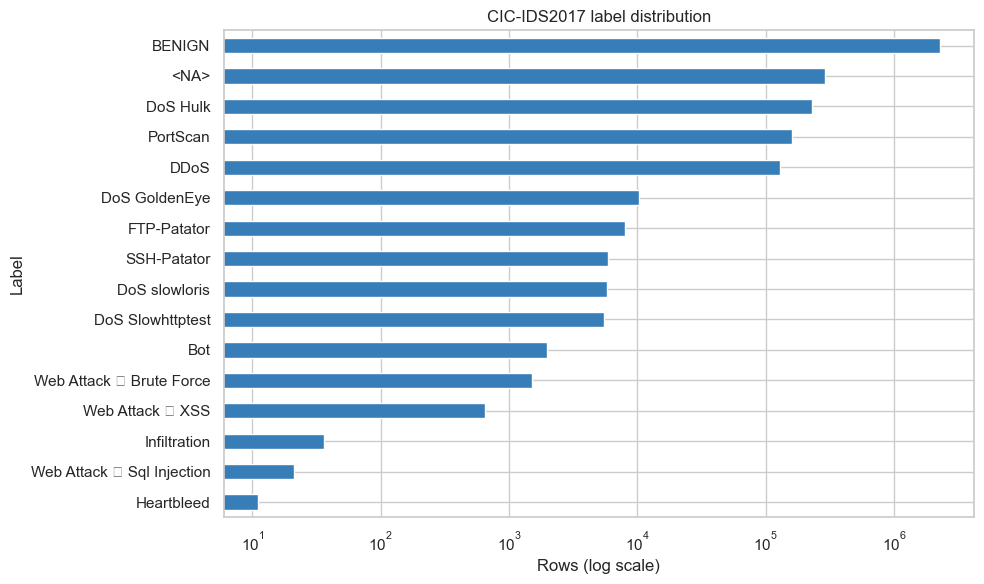

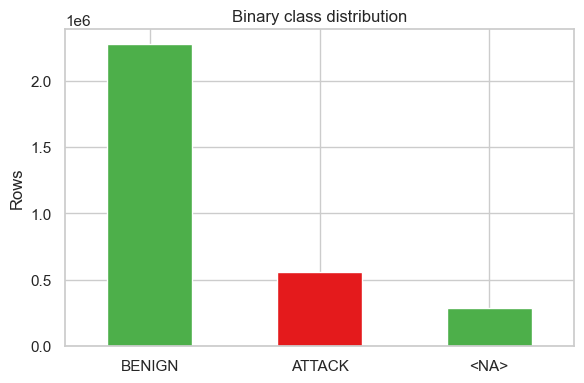

In [5]:
def distribution_table(series):
    counts = series.value_counts(dropna=False)
    return pd.DataFrame({'count': counts, 'percent': counts.div(len(series)).mul(100)})

label_distribution = distribution_table(data['label'])
binary_distribution = distribution_table(data['binary_label'])
label_distribution.to_csv(OUTPUT_DIR / 'label_distribution.csv', index_label='label')
binary_distribution.to_csv(OUTPUT_DIR / 'binary_label_distribution.csv', index_label='binary_label')
display(label_distribution)
display(binary_distribution)

ax = label_distribution.sort_values('count')['count'].plot.barh(figsize=(10, 6), color='#377eb8')
ax.set(title='CIC-IDS2017 label distribution', xlabel='Rows (log scale)', ylabel='Label', xscale='log')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'label_distribution.png', dpi=160, bbox_inches='tight'); plt.show()
ax = binary_distribution['count'].plot.bar(figsize=(6, 4), color=['#4daf4a', '#e41a1c'])
ax.set(title='Binary class distribution', xlabel='', ylabel='Rows')
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'binary_label_distribution.png', dpi=160); plt.show()

In [6]:
numeric_summary = data[numeric_columns].replace([np.inf, -np.inf], np.nan).describe().T
numeric_summary['missing_count'] = data[numeric_columns].isna().sum()
numeric_summary['inf_count'] = inf_counts.loc[numeric_columns]
numeric_summary.to_csv(OUTPUT_DIR / 'numeric_summary.csv', index_label='feature')
display(numeric_summary.head(20))

,count,mean,std,min,25%,50%,75%,max,missing_count,inf_count
source_port,2830743.0,4.112886e+04,2.229494e+04,0.0,32774.000000,50944.000000,5.841300e+04,6.553500e+04,288602,0
destination_port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.000000,80.000000,4.430000e+02,6.553500e+04,288602,0
protocol,2830743.0,9.880341e+00,5.261922e+00,0.0,6.000000,6.000000,1.700000e+01,1.700000e+01,288602,0
flow_duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.000000,31316.000000,3.204828e+06,1.200000e+08,288602,0
total_fwd_packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.000000,2.000000,5.000000e+00,2.197590e+05,288602,0
total_backward_packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.000000,2.000000,4.000000e+00,2.919220e+05,288602,0
total_length_of_fwd_packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.000000,62.000000,1.870000e+02,1.290000e+07,288602,0
total_length_of_bwd_packets,2830743.0,1.616264e+04,2.263088e+06,0.0,0.000000,123.000000,4.820000e+02,6.554530e+08,288602,0
fwd_packet_length_max,2830743.0,2.075999e+02,7.171848e+02,0.0,6.000000,37.000000,8.100000e+01,2.482000e+04,288602,0
fwd_packet_length_min,2830743.0,1.871366e+01,6.033935e+01,0.0,0.000000,2.000000,3.600000e+01,2.325000e+03,288602,0


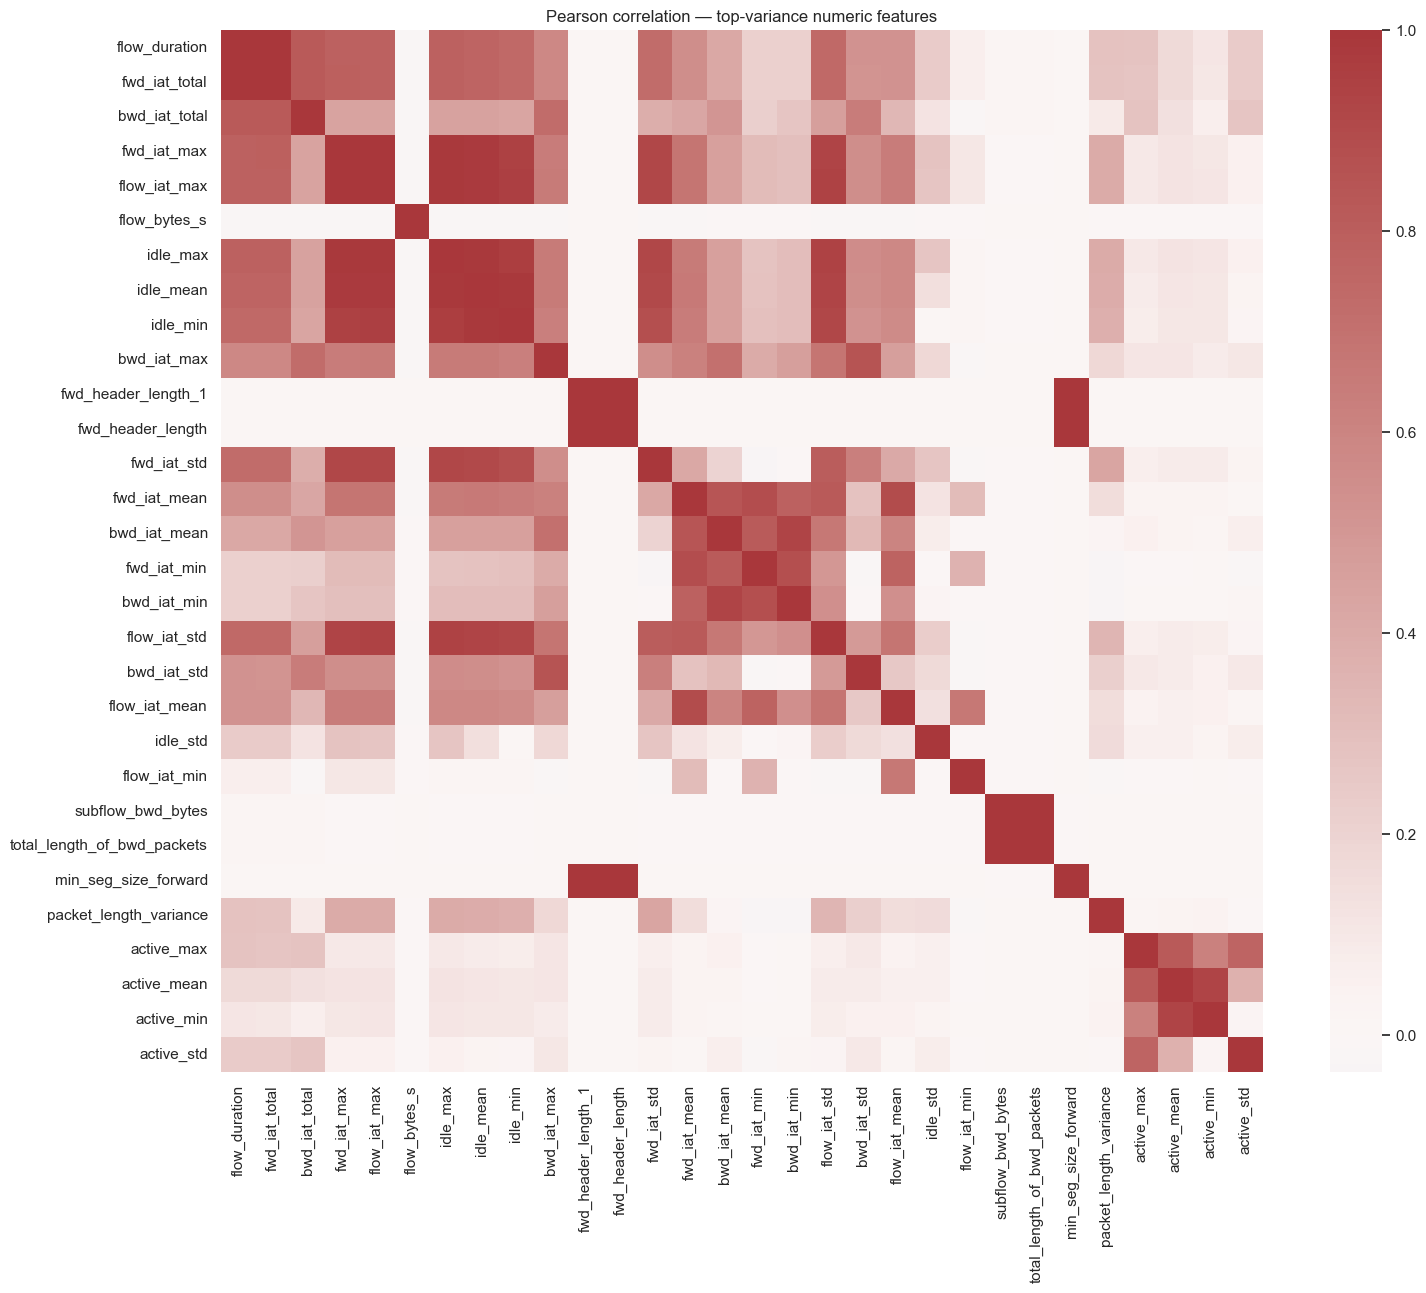

,source_port,destination_port,protocol,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,...,act_data_pkt_fwd,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min
source_port,1.000000,-0.692441,0.293302,0.087404,0.002881,0.002892,-0.009559,0.002528,-0.069729,0.049253,...,0.002465,0.006086,0.011911,0.011560,0.014122,0.010797,0.074934,0.009336,0.074271,0.074163
destination_port,-0.692441,1.000000,-0.321611,-0.152281,-0.003893,-0.003640,0.015597,-0.003035,0.094646,-0.050849,...,-0.003217,0.001448,-0.033240,-0.044791,-0.049733,-0.021328,-0.114748,0.017732,-0.109539,-0.117700
protocol,0.293302,-0.321611,1.000000,-0.263569,-0.006617,-0.005888,-0.047618,-0.005095,-0.165973,0.317229,...,-0.005135,-0.004500,-0.080594,-0.079005,-0.103484,-0.060715,-0.180125,-0.069459,-0.184654,-0.171478
flow_duration,0.087404,-0.152281,-0.263569,1.000000,0.022130,0.021144,0.097185,0.018830,0.276552,-0.104120,...,0.019024,0.001089,0.174104,0.241297,0.278886,0.111512,0.771825,0.237776,0.782656,0.743568
total_fwd_packets,0.002881,-0.003893,-0.006617,0.022130,1.000000,0.999873,0.870442,0.999930,0.012162,-0.002765,...,0.999706,-0.000808,0.007267,0.004813,0.007586,0.006084,0.000540,0.000271,0.000573,0.000472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
active_min,0.010797,-0.021328,-0.060715,0.111512,0.006084,0.006709,0.069022,0.004679,0.093088,-0.025004,...,0.005129,0.000305,0.930716,0.027166,0.617356,1.000000,0.108634,0.033143,0.112383,0.104249
idle_mean,0.074934,-0.114748,-0.180125,0.771825,0.000540,0.000209,0.031426,-0.000222,0.184675,-0.071293,...,-0.000540,0.001163,0.114739,0.039889,0.087974,0.108634,1.000000,0.145705,0.990934,0.990764
idle_std,0.009336,0.017732,-0.069459,0.237776,0.000271,0.000046,0.042102,-0.000235,0.200804,-0.029216,...,0.000110,0.000355,0.062885,0.080281,0.064191,0.033143,0.145705,1.000000,0.275228,0.011039
idle_max,0.074271,-0.109539,-0.184654,0.782656,0.000573,0.000210,0.036515,-0.000251,0.205674,-0.073299,...,-0.000504,0.001178,0.124998,0.056555,0.099613,0.112383,0.990934,0.275228,1.000000,0.963966


In [7]:
# Correlation can be expensive: use at most 100,000 rows and the 30 highest-variance features for the heatmap.
corr_source = data[numeric_columns].replace([np.inf, -np.inf], np.nan)
if len(corr_source) > 100_000:
    corr_source = corr_source.sample(100_000, random_state=42)
correlation = corr_source.corr(method='pearson')
correlation.to_csv(OUTPUT_DIR / 'correlation_matrix.csv', index_label='feature')
variances = corr_source.var().replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)
heatmap_features = variances.head(30).index.tolist()
if heatmap_features:
    plt.figure(figsize=(16, 13))
    sns.heatmap(correlation.loc[heatmap_features, heatmap_features], cmap='vlag', center=0, square=True)
    plt.title('Pearson correlation — top-variance numeric features')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=160, bbox_inches='tight'); plt.show()
display(correlation)

In [8]:
summary = {
    'sample_rows_per_file': SAMPLE_ROWS_PER_FILE,
    'files_loaded': len(csv_files),
    'rows_loaded': len(data),
    'columns_including_derived': len(data.columns),
    'feature_columns_excluding_label_and_provenance': len([c for c in data.columns if c not in {'label', 'binary_label', 'source_file'}]),
    'numeric_feature_columns': len([c for c in numeric_columns if c not in {'binary_label'}]),
    'duplicate_data_rows_ignoring_source_file': duplicate_rows,
    'missing_cells': int(data.isna().sum().sum()),
    'infinite_cells': int(inf_counts.sum()),
    'label_counts': {str(k): int(v) for k, v in data['label'].value_counts(dropna=False).items()},
}
(OUTPUT_DIR / 'dataset_summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
print(json.dumps(summary, indent=2, ensure_ascii=False))
print(f'EDA artifacts written to: {OUTPUT_DIR.resolve()}')

{
  "sample_rows_per_file": null,
  "files_loaded": 8,
  "rows_loaded": 3119345,
  "columns_including_derived": 87,
  "feature_columns_excluding_label_and_provenance": 84,
  "numeric_feature_columns": 80,
  "duplicate_data_rows_ignoring_source_file": 288804,
  "missing_cells": 24821130,
  "infinite_cells": 4376,
  "label_counts": {
    "BENIGN": 2273097,
    "<NA>": 288602,
    "DoS Hulk": 231073,
    "PortScan": 158930,
    "DDoS": 128027,
    "DoS GoldenEye": 10293,
    "FTP-Patator": 7938,
    "SSH-Patator": 5897,
    "DoS slowloris": 5796,
    "DoS Slowhttptest": 5499,
    "Bot": 1966,
    "Web Attack  Brute Force": 1507,
    "Web Attack  XSS": 652,
    "Infiltration": 36,
    "Web Attack  Sql Injection": 21,
    "Heartbleed": 11
  }
}
EDA artifacts written to: C:\Users\User\Projects\AI-Network-Intrusion-Detection\results\eda


## Interpretation checklist

Use the generated artifacts to update `docs/dataset.md` after the real CSV files are available. In Milestone 2, replace infinities with missing values, split before fitting imputers/scalers, stratify where class counts permit, and keep `source_file` out of model features.